In [119]:
# 04 · ABS & SA2 crosswalk
# Assigns every listing in vic_rentals_all.csv to its 2021 SA2 (ASGS Ed. 3), builds a suburb -> SA2 lookup,
# and joins SA2-level ABS population, income and VIF2023 projections.
# Outputs (data/curated): sa2_vic_2021.geojson, listing_sa2.parquet, suburb_sa2_crosswalk.csv, sa2_features.parquet

import numpy as np, pandas as pd, geopandas as gpd, matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from pathlib import Path

RAW, CUR, PLOTS = Path("../data/raw"), Path("../data/curated"), Path("../plots")
CUR.mkdir(parents=True, exist_ok=True); PLOTS.mkdir(exist_ok=True)
MELB = dict(xlim=(144.4, 145.6), ylim=(-38.5, -37.4))   # Greater Melbourne zoom window

def norm_code(s):
    """SA2 codes as clean 9-digit strings (Excel often reads them as floats)."""
    return s.astype(str).str.strip().str.replace(r"\.0$", "", regex=True)

def suburb_key(suburb, postcode):
    """Common join key across datasets, e.g. 'SOUTH_KINGSVILLE_3015'."""
    return (suburb.str.upper().str.strip().str.replace(r"\s+", "_", regex=True)
            + "_" + postcode.astype(int).astype(str))

def save(fig, name):
    fig.savefig(PLOTS / name, dpi=200, bbox_inches="tight"); plt.show()

In [120]:
# 1. SA2 boundaries (Victoria)
sa2 = gpd.read_file(RAW / "sa2_boundaries/SA2_2021_AUST_GDA2020.shp")
sa2 = sa2.loc[sa2["STE_CODE21"] == "2", ["SA2_CODE21", "SA2_NAME21", "AREASQKM21", "geometry"]]
sa2 = sa2[sa2.geometry.notna()].reset_index(drop=True)   # drops 'no usual address'/'migratory' pseudo-SA2s
sa2.to_file(CUR / "sa2_vic_2021.geojson", driver="GeoJSON")
print(f"{len(sa2)} Victorian SA2s")

522 Victorian SA2s


In [121]:
# 2. Listings -> SA2 (raw Domain data: drop rows without coordinates, then point-in-polygon join)
raw = pd.read_csv(RAW / "vic_rentals_all.csv")
raw = raw.dropna(subset=["lat", "lon"])
raw = raw[raw["lat"].between(-39.3, -33.9) & raw["lon"].between(140.9, 150.1)]   # VIC bbox guard

listings = gpd.GeoDataFrame(raw, geometry=gpd.points_from_xy(raw["lon"], raw["lat"]), crs="EPSG:4326").to_crs(sa2.crs)
listings = gpd.sjoin(listings, sa2[["SA2_CODE21", "SA2_NAME21", "geometry"]], how="left", predicate="within").drop(columns="index_right")
listings["suburb_key"] = suburb_key(listings["suburb"], listings["postcode"])
print(f"{len(listings):,} listings, {listings['SA2_CODE21'].isna().sum()} outside any SA2")

listings[["listing_id", "suburb_key", "postcode", "SA2_CODE21", "SA2_NAME21"]].to_parquet(CUR / "listing_sa2.parquet", index=False)

12,713 listings, 0 outside any SA2


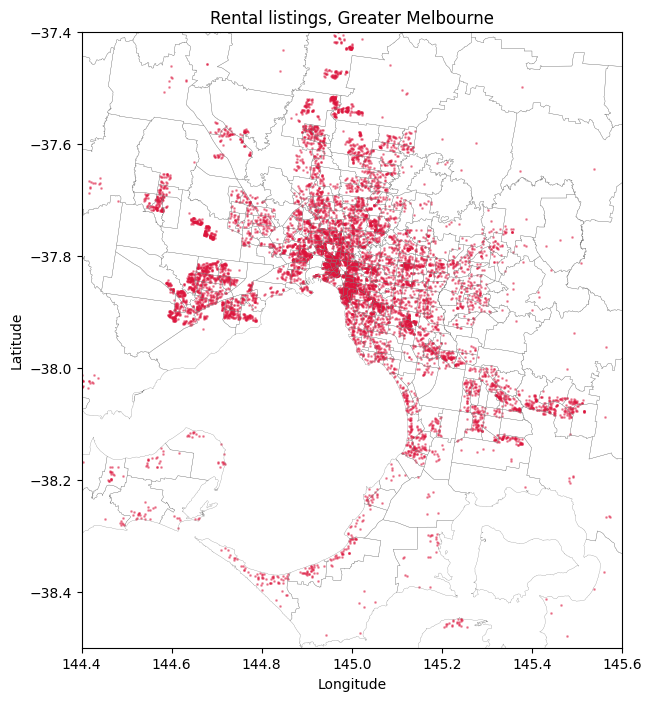

In [122]:
# Geolocation map (Sprint 1/2 checkpoint)
fig, ax = plt.subplots(figsize=(10, 8))
sa2.boundary.plot(ax=ax, lw=0.2, color="grey")
listings.plot(ax=ax, markersize=1, alpha=0.4, color="crimson")
ax.set(title=f"Domain rental listings in Victoria (n = {len(listings):,})", xlabel="Longitude", ylabel="Latitude")
fig.savefig(PLOTS / "listings_map.png", dpi=200, bbox_inches="tight")
ax.set(**MELB, title="Rental listings, Greater Melbourne")
save(fig, "listings_map_melbourne.png")

In [123]:
# 3. Suburb -> SA2 crosswalk
# Suburbs can straddle SA2s, so each suburb_key maps to the SA2 holding most of its listings; share = confidence.
counts = (listings.dropna(subset=["SA2_CODE21"])
          .groupby(["suburb_key", "postcode", "SA2_CODE21", "SA2_NAME21"]).size().rename("n").reset_index())
counts["total"] = counts.groupby("suburb_key")["n"].transform("sum")
counts["n_sa2"] = counts.groupby("suburb_key")["n"].transform("size")
counts["share"] = counts["n"] / counts["total"]

crosswalk = counts.sort_values("n", ascending=False).drop_duplicates("suburb_key").sort_values("suburb_key")
crosswalk.to_csv(CUR / "suburb_sa2_crosswalk.csv", index=False)
print(f"{len(crosswalk)} suburbs, {(crosswalk.n_sa2 > 1).sum()} span multiple SA2s, "
      f"{(crosswalk.share < 0.6).sum()} with <60% in their main SA2")

653 suburbs, 113 span multiple SA2s, 38 with <60% in their main SA2


In [124]:
# Coverage against the DFFH area lookup and the full VIC postcode list
dffh = pd.read_csv(CUR / "dffh_area_suburb_crosswalk.csv")
dffh_missing = dffh.loc[~dffh["suburb_key"].isin(crosswalk["suburb_key"]), ["dffh_area", "suburb", "postcode"]]
print(f"DFFH suburbs matched: {len(dffh) - len(dffh_missing)}/{len(dffh)}")
print(dffh_missing.to_string(index=False))

postcodes = pd.read_csv(RAW / "postcodes.csv")
postcodes["suburb_key"] = suburb_key(postcodes["suburb"], postcodes["postcode"])
print(f"VIC suburbs with at least one listing: {postcodes['suburb_key'].isin(crosswalk['suburb_key']).mean():.1%}")

DFFH suburbs matched: 204/214
                      dffh_area          suburb  postcode
                       Ballarat        Ballarat    3350.0
                        Benalla         Benalla    3671.0
Dandenong North-Endeavour Hills Dandenong North       NaN
    Eltham-Research-Montmorency        Research    3095.0
        Flora Hill-Bendigo East      Flora Hill       NaN
        Flora Hill-Bendigo East    Bendigo East       NaN
                        Mildura         Mildura    3502.0
                    Wanagaratta      Wangaratta    3676.0
                        Wodonga         Wodonga    3689.0
                   Yarra Ranges    Yarra Ranges       NaN
VIC suburbs with at least one listing: 38.3%


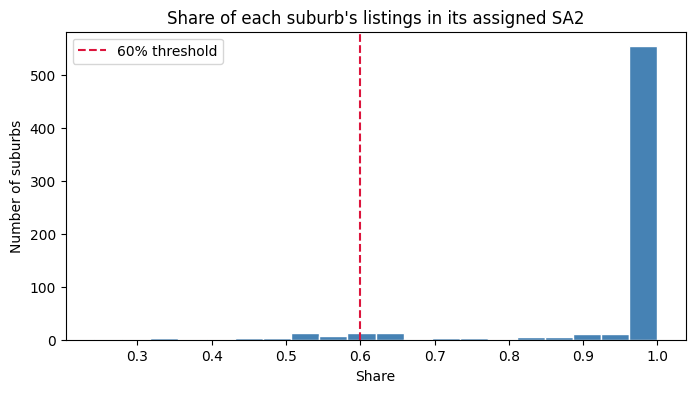

In [125]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(crosswalk["share"], bins=20, color="steelblue", edgecolor="white")
ax.axvline(0.6, color="crimson", ls="--", label="60% threshold")
ax.set(title="Share of each suburb's listings in its assigned SA2", xlabel="Share", ylabel="Number of suburbs")
ax.legend(); save(fig, "suburb_sa2_mapping_quality.png")

In [126]:
# 4. ABS estimated resident population (32180DS0003), Table 1
pop = pd.read_excel(RAW / "abs_population/32180DS0003_2001-25.xlsx", sheet_name="Table 1", header=4)
pop = pop.rename(columns={"Unnamed: 8": "SA2_CODE21", "Unnamed: 9": "SA2_NAME21"})
pop["SA2_CODE21"] = norm_code(pop["SA2_CODE21"])
pop = pop[pop["SA2_CODE21"].str.match(r"^2\d{8}$")]   # Victorian SA2s only
pop = pop[["SA2_CODE21", "SA2_NAME21", 2021, 2022, 2023, 2024, 2025]]
pop = pop.rename(columns=lambda c: f"POP_{c}" if isinstance(c, int) else c).astype({f"POP_{y}": float for y in range(2021, 2026)})
print(f"{len(pop)} SA2s with population")

522 SA2s with population


In [127]:
# ABS personal income (Table 1.4): earners, median income 2018-19 to 2022-23, mean income 2022-23
inc = pd.read_excel(RAW / "abs_income/Table 1 - Total income, earners and summary statistics by geography, 2018-19 to 2022-23.xlsx",
                    sheet_name="Table 1.4", header=None).iloc[7:]
inc = inc[[0, 6, 17, 18, 19, 20, 21, 26]]
inc.columns = (["SA2_CODE21", "EARNERS_2022_23"]
               + [f"MEDIAN_INCOME_{y}_{str(y + 1)[2:]}" for y in range(2018, 2023)]
               + ["MEAN_INCOME_2022_23"])
inc["SA2_CODE21"] = norm_code(inc["SA2_CODE21"])
inc = inc[inc["SA2_CODE21"].str.match(r"^2\d{8}$")]
num = inc.columns[1:]
inc[num] = inc[num].apply(pd.to_numeric, errors="coerce")   # 'np' (not published) -> NaN
print(f"{len(inc)} SA2s with income")

522 SA2s with income


In [128]:
# Victoria in Future 2023 projections
vif = pd.read_excel(RAW / "vic_population_projections/VIF2023_SA2_Pop_Hhold_Dwelling_Projections_to_2036_Release_2.xlsx",
                    sheet_name="Total_Population", header=9)
vif = vif[vif["Region Type"] == "SA2"].rename(columns={"SA2  code": "SA2_CODE21"})
vif["SA2_CODE21"] = norm_code(vif["SA2_CODE21"])
vif = vif[["SA2_CODE21", 2021, 2026, 2031, 2036]].rename(columns=lambda c: f"VIF_POP_{c}" if isinstance(c, int) else c)
print(f"{len(vif)} SA2s with projections")

522 SA2s with projections


In [129]:
def growth(new, old):
    """Relative growth; NaN where the base is 0 (parks, industrial SA2s)."""
    return new / old.where(old > 0) - 1

features = pop.merge(inc, on="SA2_CODE21", how="left").merge(vif, on="SA2_CODE21", how="left")
features["POP_GROWTH_2021_2025"] = growth(features["POP_2025"], features["POP_2021"])
features["INCOME_GROWTH_2018_19_2022_23"] = growth(features["MEDIAN_INCOME_2022_23"], features["MEDIAN_INCOME_2018_19"])
features["VIF_GROWTH_2026_2031"] = growth(features["VIF_POP_2031"], features["VIF_POP_2026"])
features["VIF_GROWTH_2021_2036"] = growth(features["VIF_POP_2036"], features["VIF_POP_2021"])
features.to_parquet(CUR / "sa2_features.parquet", index=False)
features.isna().sum()[lambda s: s > 0]

EARNERS_2022_23                  2
MEDIAN_INCOME_2018_19            1
MEDIAN_INCOME_2019_20            2
MEDIAN_INCOME_2020_21            1
MEDIAN_INCOME_2021_22            2
MEDIAN_INCOME_2022_23            2
MEAN_INCOME_2022_23              2
POP_GROWTH_2021_2025             4
INCOME_GROWTH_2018_19_2022_23    2
VIF_GROWTH_2026_2031             4
VIF_GROWTH_2021_2036             4
dtype: int64

In [130]:
# 5. Visualisations
# Median rent per SA2: implausible rents excluded, and only SA2s with >= 5 listings so medians are stable
rent = (listings.query("50 <= weekly_rent <= 5000").groupby("SA2_CODE21")["weekly_rent"]
        .agg(median_rent="median", n_listings="size").query("n_listings >= 5").reset_index())
gdf = sa2.merge(features, on=["SA2_CODE21", "SA2_NAME21"], how="left").merge(rent, on="SA2_CODE21", how="left")

def choropleth(col, title, label, fname, **kw):
    """Victoria-wide map plus a Greater Melbourne zoom side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    for i, ax in enumerate(axes):
        gdf.plot(col, ax=ax, legend=(i == 1), missing_kwds={"color": "lightgrey"},
                 legend_kwds={"label": label, "shrink": 0.7}, **kw)
        ax.set_axis_off()
    axes[0].set_title(f"{title} — Victoria")
    axes[1].set(**MELB, title=f"{title} — Greater Melbourne")
    save(fig, fname)

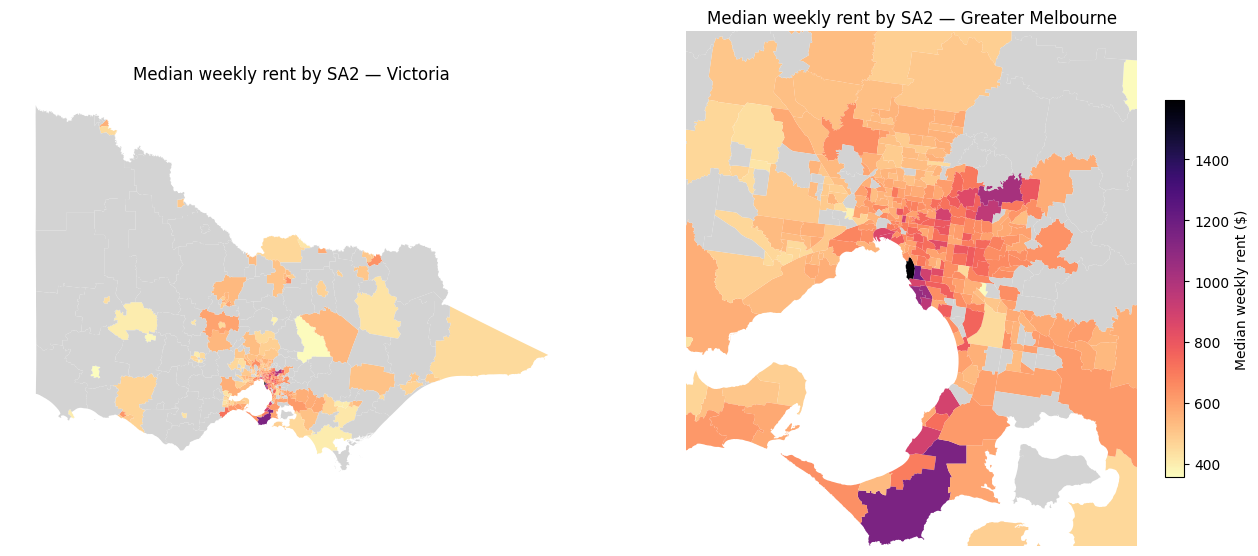

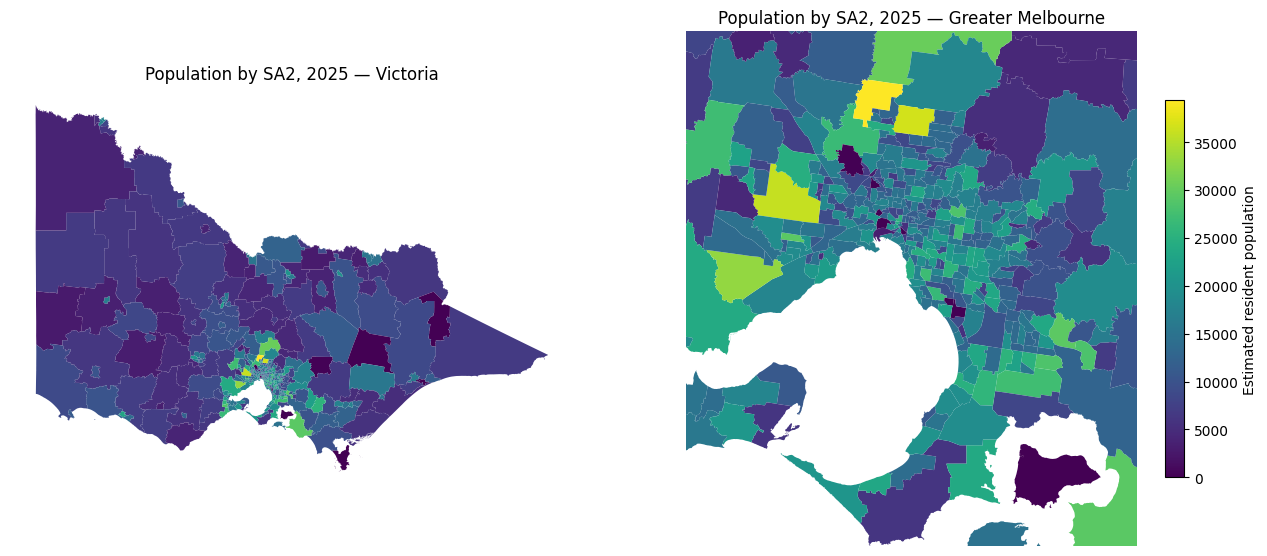

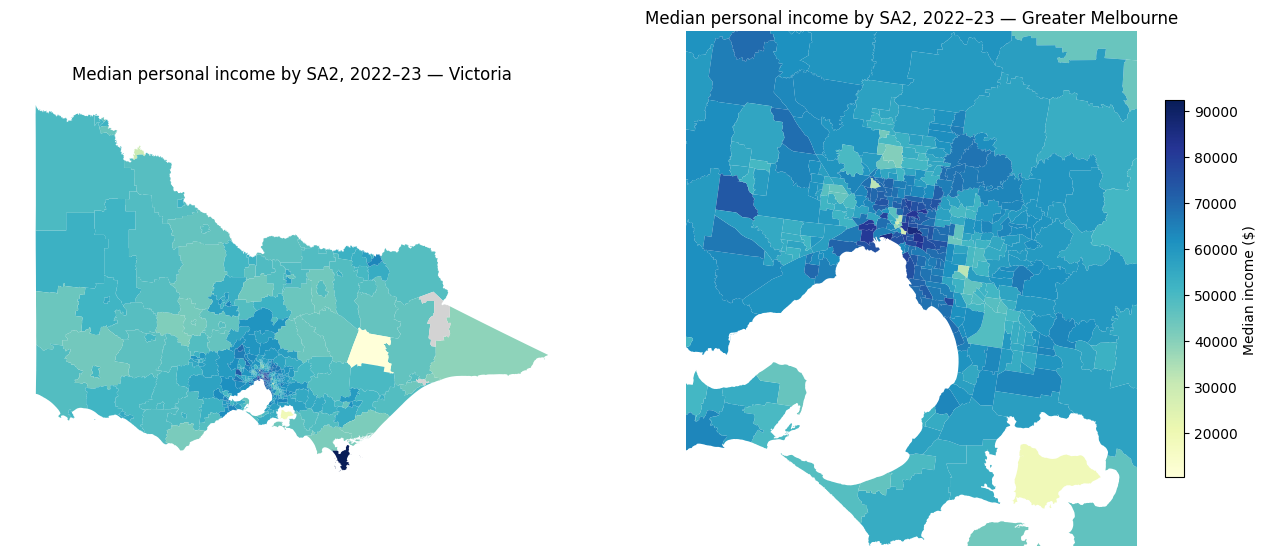

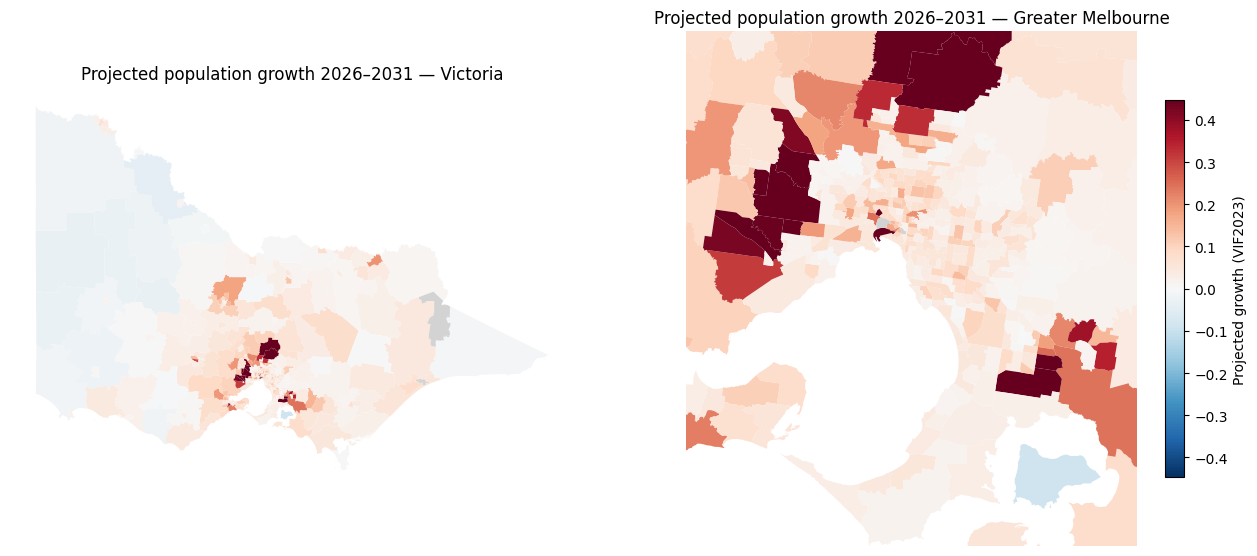

In [131]:
choropleth("median_rent", "Median weekly rent by SA2", "Median weekly rent ($)", "sa2_median_rent.png", cmap="magma_r")
choropleth("POP_2025", "Population by SA2, 2025", "Estimated resident population", "sa2_population_2025.png", cmap="viridis")
choropleth("MEDIAN_INCOME_2022_23", "Median personal income by SA2, 2022–23", "Median income ($)",
           "sa2_median_income.png", cmap="YlGnBu")

lim = gdf["VIF_GROWTH_2026_2031"].quantile([0.02, 0.98]).abs().max()
choropleth("VIF_GROWTH_2026_2031", "Projected population growth 2026–2031", "Projected growth (VIF2023)",
           "sa2_growth_2026_2031.png", cmap="RdBu_r", norm=TwoSlopeNorm(0, -lim, lim))

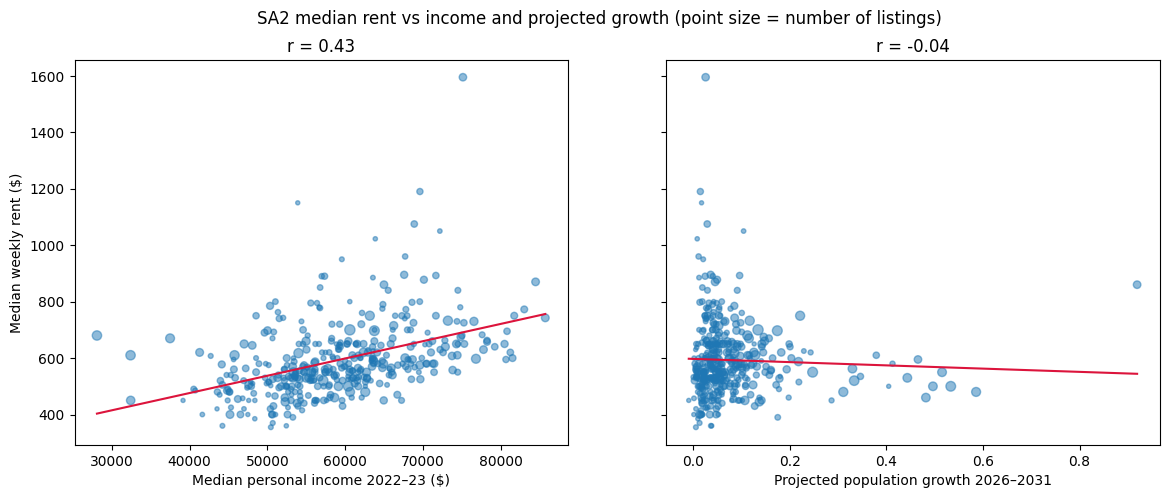

In [132]:
# Rent vs SA2 characteristics — first look at which ABS features might matter for the model
df = gdf.dropna(subset=["median_rent"])
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (col, xlabel) in zip(axes, [("MEDIAN_INCOME_2022_23", "Median personal income 2022–23 ($)"),
                                    ("VIF_GROWTH_2026_2031", "Projected population growth 2026–2031")]):
    d = df.dropna(subset=[col])
    ax.scatter(d[col], d["median_rent"], s=np.sqrt(d["n_listings"]) * 4, alpha=0.5)
    ax.plot(np.sort(d[col]), np.poly1d(np.polyfit(d[col], d["median_rent"], 1))(np.sort(d[col])), color="crimson")
    ax.set(xlabel=xlabel, title=f"r = {d[col].corr(d['median_rent']):.2f}")
axes[0].set_ylabel("Median weekly rent ($)")
fig.suptitle("SA2 median rent vs income and projected growth (point size = number of listings)")
save(fig, "sa2_rent_vs_features.png")

In [133]:
# 6. Validation checks
def check(name, ok, detail=""):
    print(f"{'PASS' if ok else 'FAIL'} | {name}" + (f" — {detail}" if detail else ""))

# SA2 boundaries
check("SA2 codes unique", sa2["SA2_CODE21"].is_unique)
check("SA2 geometries valid", sa2.is_valid.all(), f"{(~sa2.is_valid).sum()} invalid")
check("SA2 CRS is GDA2020 (EPSG:7844)", sa2.crs.to_epsg() == 7844, str(sa2.crs))

# Listings -> SA2
check("listing_id unique", listings["listing_id"].is_unique)
unmatched = listings["SA2_CODE21"].isna()
check("every listing assigned an SA2", not unmatched.any(), f"{unmatched.sum()} unmatched")
if unmatched.any():
    print(listings.loc[unmatched, ["listing_id", "suburb", "postcode", "lat", "lon"]].to_string(index=False))
dropped = len(pd.read_csv(RAW / "vic_rentals_all.csv")) - len(listings)
check("only listings without coordinates dropped", dropped == 4, f"{dropped} dropped")

# Crosswalk
check("suburb_key unique in crosswalk", crosswalk["suburb_key"].is_unique)
check("crosswalk SA2s exist in boundaries", crosswalk["SA2_CODE21"].isin(sa2["SA2_CODE21"]).all())
check("shares in (0, 1]", crosswalk["share"].between(0, 1, inclusive="right").all())
check("every listing's suburb_key in crosswalk", listings.loc[~unmatched, "suburb_key"].isin(crosswalk["suburb_key"]).all())
low = crosswalk.query("share < 0.6")
check("suburbs mostly in one SA2", len(low) / len(crosswalk) < 0.1, f"{len(low)} suburbs below 60% share")

# SA2 features
check("feature SA2 codes unique", features["SA2_CODE21"].is_unique)
check("feature SA2 codes all Victorian", features["SA2_CODE21"].str.match(r"^2\d{8}$").all())
for name, d in [("income", inc), ("VIF", vif)]:
    rate = features["SA2_CODE21"].isin(d["SA2_CODE21"]).mean()
    check(f"{name} matched to population SA2s", rate > 0.98, f"{rate:.1%}")
missing_geo = set(sa2["SA2_CODE21"]) - set(features["SA2_CODE21"])
check("boundary SA2s have population data", len(missing_geo) <= 2, f"missing: {sorted(missing_geo)}")

growth_cols = [c for c in features.columns if "GROWTH" in c]
check("no infinite growth values", not np.isinf(features[growth_cols].to_numpy(dtype=float)).any())
pop_cols = [c for c in features.columns if c.startswith(("POP_2", "VIF_POP"))]
check("populations non-negative", (features[pop_cols].fillna(0) >= 0).all().all())
zero = features.loc[features["POP_2025"] == 0, "SA2_NAME21"].tolist()
check("zero-population SA2s are known non-residential areas", len(zero) <= 5, ", ".join(zero))
med, mean = features["MEDIAN_INCOME_2022_23"], features["MEAN_INCOME_2022_23"]
check("median income <= mean income (right-skewed)", (med <= mean).mean() > 0.95, f"{(med <= mean).mean():.1%} of SA2s")

# Listing SA2s have features (so groupmates' joins won't produce NaNs)
no_feat = set(listings["SA2_CODE21"].dropna()) - set(features.dropna(subset=["POP_2025"])["SA2_CODE21"])
check("every listing SA2 has population data", not no_feat, f"{len(no_feat)} SA2s without")

# Rent sanity (flag for the cleaning stream — not fixed here)
r = listings["weekly_rent"]
odd = r.isna() | (r < 50) | (r > 5000)
check("weekly_rent plausible ($50–$5,000)", not odd.any(),
      f"{r.isna().sum()} missing, {(r < 50).sum()} below $50, {(r > 5000).sum()} above $5,000")

PASS | SA2 codes unique
PASS | SA2 geometries valid — 0 invalid
PASS | SA2 CRS is GDA2020 (EPSG:7844) — EPSG:7844
PASS | listing_id unique
PASS | every listing assigned an SA2 — 0 unmatched
PASS | only listings without coordinates dropped — 4 dropped
PASS | suburb_key unique in crosswalk
PASS | crosswalk SA2s exist in boundaries
PASS | shares in (0, 1]
PASS | every listing's suburb_key in crosswalk
PASS | suburbs mostly in one SA2 — 38 suburbs below 60% share
PASS | feature SA2 codes unique
PASS | feature SA2 codes all Victorian
PASS | income matched to population SA2s — 100.0%
PASS | VIF matched to population SA2s — 100.0%
PASS | boundary SA2s have population data — missing: []
PASS | no infinite growth values
PASS | populations non-negative
PASS | zero-population SA2s are known non-residential areas — Alps - East, Lake King, West Melbourne - Industrial, Royal Botanic Gardens Victoria
PASS | median income <= mean income (right-skewed) — 99.2% of SA2s
PASS | every listing SA2 has popul